# Modelo de Markowitz simplificado con proyección futura 2026--2031

Este cuaderno implementa una versión simplificada y rápida del modelo de Markowitz para el universo de acciones filtradas sin registros del periodo 2020--2022.

La principal corrección respecto de la versión anterior es que la valorización de los portafolios ya no se grafica como desempeño histórico dentro de la ventana usada para estimar parámetros. En cambio, el modelo:

1. usa información histórica disponible hasta 2026 para estimar retornos esperados y covarianzas;
2. optimiza un portafolio por perfil de riesgo;
3. proyecta la riqueza futura desde 2026 hasta 2031;
4. grafica la valorización esperada y bandas simuladas de incertidumbre para el horizonte de 5 años.

La estimación histórica usa 10 años efectivos de retornos semanales totales, considerando dividendos en el retorno.


## 1. Formulación usada

Sea $I=\{1,\dots,n\}$ el conjunto de acciones del subuniverso seleccionado para un perfil. Se define:

- $w_i$: proporción invertida en la acción $i$;
- $\mu_i$: retorno esperado semanal total de la acción $i$;
- $\Sigma$: matriz semanal de varianzas y covarianzas;
- $\gamma$: aversión al riesgo del perfil;
- $\bar{w}$: peso máximo permitido por acción.

La optimización resuelve:

$$
\max_w \; \mu^\top w - \frac{\gamma}{2}w^\top \Sigma w
$$

sujeto a:

$$
\sum_i w_i = 1, \qquad 0 \leq w_i \leq \bar{w}.
$$

Una vez obtenido el vector de pesos, la valorización futura se proyecta para $H=5$ años:

$$
V_{t+1}=V_t(1+R_{p,t+1}),
$$

donde $V_0=1000$ USD y $R_{p,t}$ corresponde al retorno semanal del portafolio. Para la curva esperada se usa el retorno semanal promedio estimado. Para las bandas de incertidumbre se usa simulación bootstrap a partir de la distribución histórica de retornos semanales del portafolio.


In [1]:
# ============================================================
# 1. Desacarga de los archivos
# ============================================================

# 1. Instalar gdown
!pip install gdown

# 2. Descargar el archivo ZIP desde Google Drive
# Usamos el ID del archivo compartido
!gdown --id 1fKW3XgL0gX-Oh_eNnWvKf7t7k4vXU5ED -O data.zip

# 3. Descomprimir el archivo en una carpeta llamada 'data'
import zipfile

with zipfile.ZipFile("data.zip", "r") as zip_ref:
    zip_ref.extractall("data")

# 4. Verificar que los archivos están disponibles
!ls data

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1fKW3XgL0gX-Oh_eNnWvKf7t7k4vXU5ED
From (redirected): https://drive.google.com/uc?id=1fKW3XgL0gX-Oh_eNnWvKf7t7k4vXU5ED&confirm=t&uuid=7fd524c0-ee8b-4680-ab5d-ca06802d8f5b
To: /content/data.zip
100% 166M/166M [00:03<00:00, 48.0MB/s]
Historical_Stocks_sin_pandemia


In [2]:
print("Descargando archivo de metadatos")
!gdown --id 1vQGrcoO1HhOmwKDXjERA3c6oUHm_qwH_ -O data/stocks_info.txt

Descargando archivo de metadatos
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1vQGrcoO1HhOmwKDXjERA3c6oUHm_qwH_
To: /content/data/stocks_info.txt
100% 9.31M/9.31M [00:00<00:00, 74.7MB/s]


In [3]:
from pathlib import Path
RUTA_SALIDA_MARKO = Path("/content/Resultados_Markowitz")
RUTA_SALIDA_MARKO.mkdir(parents=True, exist_ok=True)
print(f"Carpeta de resultados creada en: {RUTA_SALIDA_MARKO}")

Carpeta de resultados creada en: /content/Resultados_Markowitz


In [4]:
# ============================================================
# 2. Instalación de dependencias
# ============================================================
!pip install pandas numpy matplotlib gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 45.2 MB/s eta 0:00:00


In [5]:
# ============================================================
# 3. Imports
# ============================================================

from __future__ import annotations

import ast
import math
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import gurobipy as gp
    from gurobipy import GRB
    GUROBI_DISPONIBLE = True
except Exception:
    GUROBI_DISPONIBLE = False

try:
    from scipy.optimize import minimize
    SCIPY_DISPONIBLE = True
except Exception:
    SCIPY_DISPONIBLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print(f"Gurobi disponible: {GUROBI_DISPONIBLE}")
print(f"SciPy disponible : {SCIPY_DISPONIBLE}")

Gurobi disponible: True
SciPy disponible : True


In [6]:
# ============================================================
# 4. Configuración principal
# ============================================================

# Carpeta que contiene los CSV filtrados sin pandemia.
RUTA_TICKERS_FILTRADOS = Path(
    r"/content/data/Historical_Stocks_sin_pandemia")

# Archivo de metadatos original.
RUTA_METADATOS = Path(
    r"/content/data/stocks_info.txt")

# Carpeta de resultados.
RUTA_SALIDA = Path(
    r"/content/Resultados_Markowitz")

RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

# Columnas esperadas.
COLUMNA_FECHA = "Date"
COLUMNA_PRECIO = "Close"
COLUMNA_DIVIDENDOS = "Dividends"

# Frecuencia y ventana histórica de estimación.
SEMANAS_POR_ANIO = 52
ANIOS_HISTORIA_ESTIMACION = 8
SEMANAS_HISTORIA = ANIOS_HISTORIA_ESTIMACION * SEMANAS_POR_ANIO

# Como los registros 2020--2022 fueron eliminados, la ventana histórica se construye
# tomando las últimas 520 semanas válidas disponibles antes del inicio de la proyección,
# no las últimas 520 semanas calendario.
MIN_SEMANAS_VALIDAS = 350

# Horizonte de valorización futura.
CAPITAL_INICIAL = 1000.0
FECHA_INICIO_PROYECCION = pd.Timestamp("2026-05-03", tz="UTC")
ANIOS_PROYECCION = 5
N_SEMANAS_PROYECCION = ANIOS_PROYECCION * SEMANAS_POR_ANIO
FECHAS_PROYECCION = FECHA_INICIO_PROYECCION + pd.to_timedelta(
    np.arange(N_SEMANAS_PROYECCION + 1), unit="W"
)

# Simulaciones bootstrap para bandas de incertidumbre.
N_SIMULACIONES_PROYECCION = 5000
RANDOM_STATE_PROYECCION = 131103
PERCENTILES_PROYECCION = [5, 50, 95]

# Aceleración 1: cargar solo los activos de mayor capitalización antes de calcular retornos.
# Si quieres cargar todo el universo filtrado, cambia a None.
MAX_ACTIVOS_A_CARGAR: Optional[int] = None

# Máximo número de activos a mantener después de preparar ventana (antes de optimizar).
# Si es None, se usan todos los activos con historia válida.
MAX_ACTIVOS_MODELO: Optional[int] = 150

# Aceleración 2: frontera por simulación vectorizada.
N_PORTAFOLIOS_SIMULADOS = 12000
MAX_INTENTOS_SIMULACION = 12

# Benchmark equiponderado.
N_EMPRESAS_BENCHMARK = 20

# Estabilización numérica de covarianza.
SHRINKAGE_COVARIANZA = 0.10
EPS_COV = 1e-8

# Tasa libre de riesgo para Sharpe.
TASA_LIBRE_RIESGO_ANUAL = 0.00

# Parámetros de Gurobi.
TIME_LIMIT_GUROBI_SEG = 3
THREADS_GUROBI = 0  # 0 deja que Gurobi decida.

print("Carpeta de tickers:", RUTA_TICKERS_FILTRADOS)
print("Carpeta de salida :", RUTA_SALIDA)
print("Metadatos         :", RUTA_METADATOS)
print("Inicio proyección :", FECHA_INICIO_PROYECCION.date())
print("Fin proyección    :", FECHAS_PROYECCION[-1].date())


Carpeta de tickers: /content/data/Historical_Stocks_sin_pandemia
Carpeta de salida : /content/Resultados_Markowitz
Metadatos         : /content/data/stocks_info.txt
Inicio proyección : 2026-05-03
Fin proyección    : 2031-04-27


## 5. Perfiles de riesgo y simplificación computacional

Cada perfil define:

- número máximo de activos del subuniverso;
- aversión al riesgo $\gamma$;
- peso máximo por acción;
- proporción máxima sugerida por sector, para evitar que la selección quede dominada por una sola industria.

La idea principal es no resolver el modelo sobre las 600 acciones filtradas, sino sobre subconjuntos representativos, líquidos y computacionalmente manejables.

In [7]:
# ============================================================
# 5. Perfiles de riesgo
# ============================================================

@dataclass(frozen=True)
class PerfilRiesgo:
    nombre: str
    perdida_tolerada_anual: float
    gamma: float
    peso_maximo_accion: float
    n_activos_subuniverso: int
    max_frac_sector: float
    descripcion: str


PERFILES_RIESGO: Dict[str, PerfilRiesgo] = {
    "muy_conservador": PerfilRiesgo(
        nombre="Muy conservador",
        perdida_tolerada_anual=0.00,
        gamma=60.0,
        peso_maximo_accion=0.05,
        n_activos_subuniverso=40,
        max_frac_sector=0.30,
        descripcion="Prioriza baja volatilidad, dividendos y sectores defensivos.",
    ),
    "conservador": PerfilRiesgo(
        nombre="Conservador",
        perdida_tolerada_anual=0.05,
        gamma=35.0,
        peso_maximo_accion=0.07,
        n_activos_subuniverso=60,
        max_frac_sector=0.30,
        descripcion="Prioriza baja volatilidad y empresas grandes con desempeño estable.",
    ),
    "neutro": PerfilRiesgo(
        nombre="Neutro",
        perdida_tolerada_anual=0.15,
        gamma=18.0,
        peso_maximo_accion=0.10,
        n_activos_subuniverso=80,
        max_frac_sector=0.25,
        descripcion="Equilibra capitalización, Sharpe histórico y diversificación sectorial.",
    ),
    "arriesgado": PerfilRiesgo(
        nombre="Arriesgado",
        perdida_tolerada_anual=0.30,
        gamma=8.0,
        peso_maximo_accion=0.15,
        n_activos_subuniverso=100,
        max_frac_sector=0.30,
        descripcion="Permite mayor exposición a acciones con alto retorno histórico.",
    ),
    "muy_arriesgado": PerfilRiesgo(
        nombre="Muy arriesgado",
        perdida_tolerada_anual=0.40,
        gamma=4.0,
        peso_maximo_accion=0.20,
        n_activos_subuniverso=120,
        max_frac_sector=0.35,
        descripcion="Prioriza retorno histórico esperado, manteniendo límites de concentración.",
    ),
}

pd.DataFrame([p.__dict__ for p in PERFILES_RIESGO.values()])

,nombre,perdida_tolerada_anual,gamma,peso_maximo_accion,n_activos_subuniverso,max_frac_sector,descripcion
0,Muy conservador,0.00,60.0,0.05,40,0.30,"Prioriza baja volatilidad, dividendos y sector..."
1,Conservador,0.05,35.0,0.07,60,0.30,Prioriza baja volatilidad y empresas grandes c...
2,Neutro,0.15,18.0,0.10,80,0.25,"Equilibra capitalización, Sharpe histórico y d..."
3,Arriesgado,0.30,8.0,0.15,100,0.30,Permite mayor exposición a acciones con alto r...
4,Muy arriesgado,0.40,4.0,0.20,120,0.35,"Prioriza retorno histórico esperado, mantenien..."


In [8]:
# ============================================================
# 6. Lectura de metadatos
# ============================================================

def limpiar_texto_diccionario(texto: str) -> str:
    """
    Limpia comillas curvas y valores problemáticos antes de evaluar el diccionario.
    """
    texto = texto.replace("‘", "'").replace("’", "'").replace("“", '"').replace("”", '"')
    texto = texto.replace("nan", "None").replace("NaN", "None")
    return texto


def leer_metadatos_stocks(ruta_metadatos: Path) -> pd.DataFrame:
    """
    Lee stocks_info.txt con formato aproximado:
        TICKER;{'sector': '...', 'industry': '...', 'marketCap': ...}
    """
    if not ruta_metadatos.exists():
        print(f"No se encontró el archivo de metadatos: {ruta_metadatos}")
        return pd.DataFrame(columns=["ticker", "sector", "industry", "marketCap", "quoteType", "shortName", "longName"])

    registros = []

    with open(ruta_metadatos, "r", encoding="latin-1") as archivo:
        for linea in archivo:
            linea = linea.strip()
            if not linea or ";" not in linea:
                continue

            ticker, info_txt = linea.split(";", 1)
            ticker = ticker.strip().upper()
            info_txt = limpiar_texto_diccionario(info_txt)

            try:
                info = ast.literal_eval(info_txt)
            except Exception:
                info = {}

            if not isinstance(info, dict):
                info = {}

            registros.append({
                "ticker": ticker,
                "sector": info.get("sector", "Unknown"),
                "industry": info.get("industry", "Unknown"),
                "marketCap": info.get("marketCap", np.nan),
                "quoteType": info.get("quoteType", np.nan),
                "shortName": info.get("shortName", np.nan),
                "longName": info.get("longName", np.nan),
            })

    df_meta = pd.DataFrame(registros)
    df_meta["marketCap"] = pd.to_numeric(df_meta["marketCap"], errors="coerce")
    return df_meta


df_metadatos = leer_metadatos_stocks(RUTA_METADATOS)
print(f"Metadatos cargados: {len(df_metadatos)} tickers")
df_metadatos.head()

Metadatos cargados: 1406 tickers


,ticker,sector,industry,marketCap,quoteType,shortName,longName
0,MAR,Consumer Cyclical,Lodging,8.315480e+10,EQUITY,Marriott International,"Marriott International, Inc."
1,A,Healthcare,Diagnostics & Research,3.153945e+10,EQUITY,"Agilent Technologies, Inc.","Agilent Technologies, Inc."
2,AACI,Unknown,Unknown,NaN,EQUITY,Armada Acquisition Corp. II,NaN
3,AACT,Unknown,Unknown,NaN,NaN,NaN,NaN
4,AAL,Industrials,Airlines,6.801137e+09,EQUITY,"American Airlines Group, Inc.",American Airlines Group Inc.


## 6. Carga de datos y retornos totales

Para cada acción se calcula el retorno total semanal:

$$
R_{i,t}=\frac{P_{i,t}-P_{i,t-1}+D_{i,t}}{P_{i,t-1}},
$$

con $P_{i,t}$ como precio de cierre semanal y $D_{i,t}$ como dividendos pagados durante la semana. El uso de dividendos es importante porque el cliente recibe tanto ganancias de capital como flujos por dividendos.

La base usada ya excluye los registros 2020--2022. Por ello, al construir la ventana histórica de estimación se consideran las últimas 520 semanas válidas disponibles antes de 2026, evitando que el periodo pandémico aparezca como un bloque de datos faltantes dentro de la ventana.


In [9]:
# ============================================================
# 7. Funciones de lectura de CSV y cálculo de retornos semanales
# ============================================================

def obtener_ticker_desde_nombre(nombre_archivo: str) -> str:
    '''Extrae el ticker desde distintos formatos de nombre de archivo.'''
    nombre = Path(nombre_archivo).stem
    nombre = nombre.replace("stock_return_", "")
    nombre = nombre.replace("stock_returns_", "")
    nombre = nombre.replace("stock return ", "")
    nombre = nombre.replace("stock returns ", "")
    nombre = nombre.replace("stock-return-", "")
    return nombre.strip().upper()


def listar_csv_preseleccionados(ruta: Path, df_meta: pd.DataFrame) -> List[Path]:
    '''Lista CSV y, si corresponde, conserva solo los de mayor capitalización.'''
    if not ruta.exists():
        raise FileNotFoundError(f"No existe la carpeta de tickers filtrados:\n{ruta}")

    archivos = sorted(ruta.glob("*.csv"))
    if not archivos:
        raise FileNotFoundError(f"No se encontraron CSV en:\n{ruta}")

    mapa_archivos = {obtener_ticker_desde_nombre(a.name): a for a in archivos}

    if MAX_ACTIVOS_A_CARGAR is None or df_meta.empty:
        return archivos

    ranking = (
        df_meta[df_meta["ticker"].isin(mapa_archivos.keys())]
        .sort_values("marketCap", ascending=False)
        ["ticker"]
        .dropna()
        .tolist()
    )
    seleccion = [mapa_archivos[t] for t in ranking if t in mapa_archivos][:MAX_ACTIVOS_A_CARGAR]

    # Si faltan archivos por metadatos incompletos, se completa con el resto.
    if len(seleccion) < min(MAX_ACTIVOS_A_CARGAR, len(archivos)):
        ya = {obtener_ticker_desde_nombre(a.name) for a in seleccion}
        for archivo in archivos:
            t = obtener_ticker_desde_nombre(archivo.name)
            if t not in ya:
                seleccion.append(archivo)
            if len(seleccion) >= MAX_ACTIVOS_A_CARGAR:
                break

    return seleccion


def leer_csv_accion(ruta_csv: Path) -> Optional[pd.DataFrame]:
    '''Lee un CSV de acción y conserva fecha, cierre y dividendos.'''
    try:
        df = pd.read_csv(ruta_csv)
    except Exception as error:
        print(f"No se pudo leer {ruta_csv.name}: {error}")
        return None

    if COLUMNA_FECHA not in df.columns or COLUMNA_PRECIO not in df.columns:
        return None

    if COLUMNA_DIVIDENDOS not in df.columns:
        df[COLUMNA_DIVIDENDOS] = 0.0

    df[COLUMNA_FECHA] = pd.to_datetime(df[COLUMNA_FECHA], errors="coerce", utc=True)
    df[COLUMNA_PRECIO] = pd.to_numeric(df[COLUMNA_PRECIO], errors="coerce")
    df[COLUMNA_DIVIDENDOS] = pd.to_numeric(df[COLUMNA_DIVIDENDOS], errors="coerce").fillna(0.0)

    df = df.dropna(subset=[COLUMNA_FECHA, COLUMNA_PRECIO])
    df = df[df[COLUMNA_PRECIO] > 0]

    df = df.sort_values(COLUMNA_FECHA)
    if df.empty:
        return None

    df = (
        df.groupby(COLUMNA_FECHA, as_index=False)
        .agg({COLUMNA_PRECIO: "last", COLUMNA_DIVIDENDOS: "sum"})
        .sort_values(COLUMNA_FECHA)
    )
    return df


def cargar_series_diarias(ruta_tickers: Path, df_meta: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    '''Carga precios y dividendos diarios para los CSV preseleccionados.'''
    archivos = listar_csv_preseleccionados(ruta_tickers, df_meta)
    print(f"Archivos CSV a cargar: {len(archivos)}")

    precios = {}
    dividendos = {}
    tiene_dividendos = {}

    t0 = time.time()
    for i, ruta_csv in enumerate(archivos, start=1):
        ticker = obtener_ticker_desde_nombre(ruta_csv.name)
        df = leer_csv_accion(ruta_csv)
        if df is None or df.empty:
            continue
        precios[ticker] = df.set_index(COLUMNA_FECHA)[COLUMNA_PRECIO]
        dividendos[ticker] = df.set_index(COLUMNA_FECHA)[COLUMNA_DIVIDENDOS]
        tiene_dividendos[ticker] = bool(df[COLUMNA_DIVIDENDOS].sum() > 0)

        if i % 50 == 0:
            print(f"  Leídos {i}/{len(archivos)} archivos...")

    if not precios:
        raise ValueError("No se pudo cargar ningún ticker válido.")

    close_daily = pd.DataFrame(precios).sort_index()
    dividends_daily = pd.DataFrame(dividendos).reindex(close_daily.index).fillna(0.0)
    serie_tiene_dividendos = pd.Series(tiene_dividendos, name="tiene_dividendos")

    print(f"Tiempo de carga: {time.time() - t0:.2f} segundos")
    print(f"Tickers cargados: {close_daily.shape[1]}")
    return close_daily, dividends_daily, serie_tiene_dividendos


def construir_retornos_semanales_totales(close_daily: pd.DataFrame, dividends_daily: pd.DataFrame) -> pd.DataFrame:
    '''Convierte datos diarios en retornos semanales totales.'''
    close_weekly = close_daily.resample("W-FRI").last()
    dividends_weekly = dividends_daily.resample("W-FRI").sum().reindex(close_weekly.index).fillna(0.0)

    returns = (close_weekly - close_weekly.shift(1) + dividends_weekly) / close_weekly.shift(1)
    returns = returns.replace([np.inf, -np.inf], np.nan)

    # Limpieza de retornos extremos probablemente asociados a errores de datos.
    returns = returns.where((returns >= -0.95) & (returns <= 3.0))
    return returns

In [10]:
# ============================================================
# 8. Carga efectiva de datos
# ============================================================

close_daily, dividends_daily, serie_tiene_dividendos = cargar_series_diarias(
    RUTA_TICKERS_FILTRADOS,
    df_metadatos,
)

retornos_semanales = construir_retornos_semanales_totales(close_daily, dividends_daily)

print("Dimensión matriz semanal:", retornos_semanales.shape)
print("Rango de fechas:", retornos_semanales.index.min(), "a", retornos_semanales.index.max())
retornos_semanales.tail()

Archivos CSV a cargar: 601
  Leídos 50/601 archivos...
  Leídos 100/601 archivos...
  Leídos 150/601 archivos...
  Leídos 200/601 archivos...
  Leídos 250/601 archivos...
  Leídos 300/601 archivos...
  Leídos 350/601 archivos...
  Leídos 400/601 archivos...
  Leídos 450/601 archivos...
  Leídos 500/601 archivos...
  Leídos 550/601 archivos...
  Leídos 600/601 archivos...
Tiempo de carga: 32.11 segundos
Tickers cargados: 601
Dimensión matriz semanal: (3350, 601)
Rango de fechas: 1962-01-05 00:00:00+00:00 a 2026-03-13 00:00:00+00:00


,A,AAL,AAPL,AB,ABBV,ABCB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEG,AEP,AES,AFG,AFL,AGO,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALL,AMAT,AMCR,AMD,AME,AMG,AMGN,AMP,AMT,AMZN,AON,AOS,APA,APAM,APD,APH,APO,APTV,ARE,ASB,ATO,AUB,AVB,AVGO,AVY,AWK,AX,AXON,AXP,AXS,AZO,BA,BAC,...,TTWO,TXN,TXT,TYL,UAL,UBS,UBSI,UDR,UHS,ULTA,UMBF,UNH,UNM,UNP,UPS,URI,USB,V,VLO,VLY,VMC,VRSK,VRSN,VRTX,VTR,VTRS,VZ,WAB,WAFD,WAL,WAT,WBD,WBS,WDC,WEC,WELL,WF,WFC,WM,WMB,WMT,WRB,WSBC,WSFS,WST,WTFC,WTM,WTW,WU,WULF,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-02-13 00:00:00+00:00,-0.029094,-0.089239,-0.078529,0.035760,0.036119,-0.022341,0.016692,-0.025458,-0.068116,-0.016432,0.051958,0.047942,-0.083204,-0.038186,0.055952,-0.038071,0.092094,0.014330,0.007209,-0.019121,-0.016068,0.020203,-0.106161,-0.137139,0.175431,0.018241,-0.004424,-0.000193,0.100462,0.039859,-0.005373,-0.009271,0.079509,-0.026109,-0.122130,0.121621,-0.054821,-0.059467,0.018739,0.016752,0.015571,-0.011938,0.077002,-0.059836,0.034232,-0.061002,-0.051754,0.045921,-0.019239,0.013576,-0.023279,0.022401,0.087740,-0.036927,0.037349,-0.060281,-0.043931,0.048054,-0.000288,-0.070405,...,-0.009816,0.021315,0.027766,-0.127487,-0.057113,-0.043726,-0.030756,0.014381,0.074350,-0.010096,-0.041319,0.059787,-0.039163,0.031906,0.016192,-0.028955,-0.049432,-0.048800,-0.012384,-0.016047,0.012140,0.011781,-0.022929,0.028352,0.032586,0.081619,0.058303,0.039542,-0.008425,-0.012607,-0.151905,0.023026,-0.016499,-0.003539,0.056605,0.075541,0.165969,-0.074385,0.034084,0.080096,0.020659,-0.010084,-0.032726,-0.049659,0.006186,-0.047165,0.001405,-0.128166,-0.066148,0.137859,0.004129,-0.038742,0.074967,0.009569,-0.098719,-0.014485,0.072739,0.052586,-0.048023,-0.006043
2026-02-20 00:00:00+00:00,-0.023130,-0.020893,0.034405,0.018806,-0.028898,-0.003451,-0.004171,0.001118,-0.039602,-0.020305,0.053189,-0.008552,0.011126,-0.018338,-0.008290,-0.006596,-0.004387,0.014128,0.009771,0.002951,0.023743,0.027725,0.039658,0.038666,-0.157391,0.012444,0.017401,-0.005494,0.060293,0.007986,-0.034584,0.016321,-0.127657,0.015060,-0.004180,-0.024935,0.056945,0.010476,-0.032936,0.040831,-0.023245,0.005148,0.029444,-0.034771,-0.066080,0.022099,0.025494,0.009596,0.010440,0.006868,0.023003,0.005720,-0.030936,0.000411,0.009868,0.025718,0.031026,-0.028418,-0.044987,0.009705,...,0.031239,-0.028431,0.027322,0.043002,0.034221,0.013813,0.003626,-0.024153,-0.018398,-0.000746,-0.014910,-0.010880,0.028057,0.020792,0.006548,0.045471,0.016814,0.021873,0.002947,-0.009637,-0.068244,0.007119,-0.006866,-0.029646,0.008212,0.009512,0.004897,0.036520,0.009732,0.010880,0.030801,0.027153,0.027555,0.013992,-0.012523,-0.012006,0.045550,0.019775,-0.017952,0.009685,-0.081410,0.019799,0.005457,0.012874,-0.037407,0.016651,0.018308,0.048898,-0.034375,-0.076876,-0.054953,0.013052,-0.000490,-0.007881,0.004528,0.026569,0.023847,-0.034805,0.020242,0.016818
2026-02-27 00:00:00+00:00,-0.012368,-0.038263,-0.001512,-0.010335,0.032338,-0.072495,0.036895,0.016855,-0.030787,0.014694,0.002141,0.017089,-0.000513,0.083223,0.029350,-0.003984,0.034398,0.046638,0.021273,-0.009647,-0.024663,0.000622,0.023539,0.053993,0.044813,0.060860,0.000421,0.039492,-0.008205,-0.015169,0.000300,0.024453,0.064342,0.035784,-0.003328,0.024291,-0.000524,0.031993,0.002442,0.045079,-0.031731,-0.019596,-0.032971,-0.126295,-0.075782,0.007269,-0.075280,0.043452,-0.088315,-0.000958,-0.039381,-0.002895,0.051480,-0.107891,0.250029,-0.107690,0.006761,0.001883,-0.019394,-0.060874,...,0.058882,-0.034679,-0.021038,0.118861,-0.059542,-0.026779,-0.067299,0.008878,-0.105818,0.002782,-0.086480,0.011276,-0.026069,0.006208,-0.006596,-0.076019,-0.068190,-0.002524,0.019327,-0.056138,0.015428,0.137370,0.055718,0.041791,0.002560,-0.062186,0.018071,-0.003135,-0.061446,-0.139674,-0.041850,-0.020174,-0.013134,-0.020384,0.022914,0.001957,-0.111401,-0.081736,0.045721,0.023842,0.040328,0.011269,-0.053731,-0.061336,0.054827,-0.078311,

In [11]:
# ============================================================
# 8.5 Diagnóstico: verificar cobertura de datos antes de proyectar
# ============================================================

print(f"Dimensión total de retornos_semanales: {retornos_semanales.shape}")
print(f"Rango de fechas disponible: {retornos_semanales.index.min()} a {retornos_semanales.index.max()}")
print(f"Total de semanas calendario en matriz: {len(retornos_semanales)}")
print(f"Total de tickers: {retornos_semanales.shape[1]}")
print()

print(f"Fecha de inicio de proyección: {FECHA_INICIO_PROYECCION}")
print(f"Semanas de historia efectiva requeridas: {SEMANAS_HISTORIA}")
print(f"Mínimo de semanas válidas por ticker: {MIN_SEMANAS_VALIDAS}")
print()

# Se usan solo fechas conocidas antes del inicio de la proyección.
retornos_pre_proyeccion = retornos_semanales.loc[retornos_semanales.index < FECHA_INICIO_PROYECCION].copy()

# Se eliminan semanas completamente vacías. Esto es clave porque la pandemia 2020--2022
# fue eliminada de los CSV, pero el resample semanal puede crear semanas calendario vacías.
retornos_pre_proyeccion_no_vacios = retornos_pre_proyeccion.dropna(how="all")
ventana_test = retornos_pre_proyeccion_no_vacios.tail(SEMANAS_HISTORIA).copy()

conteo_test = ventana_test.notna().sum()
print(f"Ventana efectiva de estimación:")
print(f"  - Fecha inicial: {ventana_test.index.min()}")
print(f"  - Fecha final  : {ventana_test.index.max()}")
print(f"  - Semanas no vacías consideradas: {len(ventana_test)}")
print(f"  - Tickers con historia suficiente: {(conteo_test >= MIN_SEMANAS_VALIDAS).sum()}")
print(f"  - Min semanas válidas por ticker: {conteo_test.min()}")
print(f"  - Max semanas válidas por ticker: {conteo_test.max()}")
print(f"  - Mediana semanas válidas: {conteo_test.median()}")
print()

print("Sensibilidad del número de tickers al mínimo de semanas válidas:")
for umbral in [350, 400, 450, 480, 500, 520]:
    count = (conteo_test >= umbral).sum()
    print(f"  Tickers con {umbral}+ semanas: {count}")


Dimensión total de retornos_semanales: (3350, 601)
Rango de fechas disponible: 1962-01-05 00:00:00+00:00 a 2026-03-13 00:00:00+00:00
Total de semanas calendario en matriz: 3350
Total de tickers: 601

Fecha de inicio de proyección: 2026-05-03 00:00:00+00:00
Semanas de historia efectiva requeridas: 416
Mínimo de semanas válidas por ticker: 350

Ventana efectiva de estimación:
  - Fecha inicial: 2015-03-27 00:00:00+00:00
  - Fecha final  : 2026-03-13 00:00:00+00:00
  - Semanas no vacías consideradas: 416
  - Tickers con historia suficiente: 601
  - Min semanas válidas por ticker: 410
  - Max semanas válidas por ticker: 416
  - Mediana semanas válidas: 416.0

Sensibilidad del número de tickers al mínimo de semanas válidas:
  Tickers con 350+ semanas: 601
  Tickers con 400+ semanas: 601
  Tickers con 450+ semanas: 0
  Tickers con 480+ semanas: 0
  Tickers con 500+ semanas: 0
  Tickers con 520+ semanas: 0


In [12]:
# ============================================================
# 9. Ventana histórica de estimación y métricas individuales
# ============================================================

def preparar_ventana_10_anios(retornos: pd.DataFrame) -> pd.DataFrame:
    '''Prepara una ventana histórica de 10 años efectivos antes de la fecha de proyección.

    La base filtrada no contiene registros 2020--2022. Si se tomaran simplemente las
    últimas 520 semanas calendario, una parte importante de la ventana serían semanas
    vacías. Por eso se eliminan las semanas completamente vacías y luego se toman las
    últimas 520 semanas con información disponible antes de FECHA_INICIO_PROYECCION.
    '''
    historico = retornos.loc[retornos.index < FECHA_INICIO_PROYECCION].copy()
    historico = historico.dropna(how="all")

    if len(historico) < SEMANAS_HISTORIA:
        print(
            f"Advertencia: hay solo {len(historico)} semanas no vacías antes de la proyección; "
            f"se usarán todas las disponibles."
        )
        ventana = historico.copy()
    else:
        ventana = historico.tail(SEMANAS_HISTORIA).copy()

    conteo_validos = ventana.notna().sum()
    tickers_validos = conteo_validos[conteo_validos >= MIN_SEMANAS_VALIDAS].index.tolist()
    ventana = ventana[tickers_validos]

    if ventana.empty:
        raise ValueError(
            "No quedaron activos con historia suficiente para estimar el modelo. "
            "Prueba reducir MIN_SEMANAS_VALIDAS o revisar la carpeta filtrada."
        )

    # Imputación simple y rápida de faltantes residuales dentro de la ventana.
    # Se usa la mediana de cada activo para no perder activos por algunos faltantes aislados.
    ventana = ventana.apply(lambda col: col.fillna(col.median()), axis=0)
    return ventana


def estimar_parametros(retornos_ventana: pd.DataFrame) -> Tuple[pd.Series, pd.DataFrame]:
    '''Estima retorno esperado semanal y matriz de covarianzas con shrinkage.'''
    mu = retornos_ventana.mean()
    cov = retornos_ventana.cov()

    # Shrinkage hacia matriz diagonal para mejorar estabilidad y condición numérica.
    diag = np.diag(np.diag(cov.values))
    cov_shrunk = (1 - SHRINKAGE_COVARIANZA) * cov.values + SHRINKAGE_COVARIANZA * diag
    cov_shrunk = (cov_shrunk + cov_shrunk.T) / 2

    # Corrección PSD mínima.
    valores, vectores = np.linalg.eigh(cov_shrunk)
    valores = np.clip(valores, EPS_COV, None)
    cov_psd = vectores @ np.diag(valores) @ vectores.T

    cov_df = pd.DataFrame(cov_psd, index=cov.index, columns=cov.columns)
    return mu, cov_df


def construir_estadisticas_activos(retornos_ventana: pd.DataFrame, df_meta: pd.DataFrame, tiene_dividendos: pd.Series) -> pd.DataFrame:
    '''Construye tabla de estadísticas individuales para selección de subuniversos.'''
    mu = retornos_ventana.mean() * SEMANAS_POR_ANIO
    vol = retornos_ventana.std() * np.sqrt(SEMANAS_POR_ANIO)
    sharpe = (mu - TASA_LIBRE_RIESGO_ANUAL) / vol.replace(0, np.nan)

    stats = pd.DataFrame({
        "ticker": retornos_ventana.columns,
        "retorno_anual_hist": mu.values,
        "volatilidad_anual_hist": vol.values,
        "sharpe_hist": sharpe.values,
    })
    stats = stats.merge(df_meta, on="ticker", how="left")
    stats["tiene_dividendos"] = stats["ticker"].map(tiene_dividendos).fillna(False).astype(bool)
    stats["marketCap"] = pd.to_numeric(stats["marketCap"], errors="coerce")
    stats["sector"] = stats["sector"].fillna("Unknown")
    stats["industry"] = stats["industry"].fillna("Unknown")
    return stats


retornos_10_anios = preparar_ventana_10_anios(retornos_semanales)
mu_base, cov_base = estimar_parametros(retornos_10_anios)
df_stats_activos = construir_estadisticas_activos(retornos_10_anios, df_metadatos, serie_tiene_dividendos)

print("Ventana histórica efectiva usada para estimación:")
print(f"  Fecha inicial: {retornos_10_anios.index.min()}")
print(f"  Fecha final  : {retornos_10_anios.index.max()}")
print(f"  Semanas      : {len(retornos_10_anios)}")
print(f"  Activos      : {retornos_10_anios.shape[1]}")
df_stats_activos.sort_values("marketCap", ascending=False).head(10)


Ventana histórica efectiva usada para estimación:
  Fecha inicial: 2015-03-27 00:00:00+00:00
  Fecha final  : 2026-03-13 00:00:00+00:00
  Semanas      : 416
  Activos      : 601


,ticker,retorno_anual_hist,volatilidad_anual_hist,sharpe_hist,sector,industry,marketCap,quoteType,shortName,longName,tiene_dividendos
407,NVDA,0.706047,0.438655,1.609571,Technology,Semiconductors,4.380976e+12,EQUITY,NVIDIA Corporation,NVIDIA Corporation,True
2,AAPL,0.245886,0.254960,0.964408,Technology,Consumer Electronics,3.676245e+12,EQUITY,Apple Inc.,Apple Inc.,True
258,GOOGL,0.301140,0.268865,1.120043,Communication Services,Internet Content & Information,3.656681e+12,EQUITY,Alphabet Inc.,Alphabet Inc.,True
257,GOOG,0.301012,0.270028,1.114743,Communication Services,Internet Content & Information,3.646762e+12,EQUITY,Alphabet Inc.,Alphabet Inc.,True
381,MSFT,0.289005,0.210594,1.372333,Technology,Software - Infrastructure,2.939877e+12,EQUITY,Microsoft Corporation,Microsoft Corporation,True
36,AMZN,0.347390,0.277421,1.252210,Consumer Cyclical,Internet Retail,2.229321e+12,EQUITY,"Amazon.com, Inc.","Amazon.com, Inc.",False
360,META,0.355516,0.308231,1.153408,Communication Services,Internet Content & Information,1.552413e+12,EQUITY,"Meta Platforms, Inc.","Meta Platforms, Inc.",True
50,AVGO,0.441548,0.388234,1.137324,Technology,Semiconductors,1.527449e+12,EQUITY,Broadcom Inc.,Broadcom Inc.,True
538,TSLA,0.374214,0.507450,0.737439,Consumer Cyclical,Auto Manufacturers,1.467951e+12,EQUITY,"Tesla, Inc.","Tesla, Inc.",False
581,WMT,0.224549,0.198332,1.132186,Consumer Defensive,Discount Stores,1.008725e+12,EQUITY,Walmart Inc.,Walmart Inc.,True


## 7. Selección rápida de subuniversos por perfil

La selección de activos ocurre antes de optimizar. Esto es clave para reducir el costo computacional, porque el número de términos de covarianza crece aproximadamente como $n^2$.

El score de selección cambia por perfil:

- perfiles conservadores: priorizan baja volatilidad, capitalización y dividendos;
- perfil neutro: balancea capitalización, Sharpe y diversificación;
- perfiles arriesgados: dan mayor peso a retorno histórico y Sharpe.

In [13]:
# ============================================================
# 10. Selección de subuniversos por perfil
# ============================================================

def rank_pct_asc(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, ascending=True).fillna(0.0)


def rank_pct_desc(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, ascending=False).fillna(0.0)


def seleccionar_con_limite_sector(df: pd.DataFrame, n: int, max_frac_sector: float) -> List[str]:
    '''Selecciona tickers ordenados por score respetando un límite aproximado por sector.'''
    max_por_sector = max(1, math.ceil(n * max_frac_sector))
    seleccion = []
    conteo_sector = {}

    for _, fila in df.sort_values("score", ascending=False).iterrows():
        sector = fila.get("sector", "Unknown")
        if conteo_sector.get(sector, 0) < max_por_sector:
            seleccion.append(fila["ticker"])
            conteo_sector[sector] = conteo_sector.get(sector, 0) + 1
        if len(seleccion) >= n:
            break

    # Si el límite sectorial fue muy estricto, se completa con los mejores restantes.
    if len(seleccion) < n:
        restantes = [t for t in df.sort_values("score", ascending=False)["ticker"] if t not in seleccion]
        seleccion.extend(restantes[: n - len(seleccion)])

    return seleccion[:n]


def seleccionar_subuniverso_perfil(perfil: PerfilRiesgo, stats: pd.DataFrame) -> List[str]:
    '''Construye subuniverso operativo para un perfil.'''
    df = stats.copy()
    df = df.dropna(subset=["retorno_anual_hist", "volatilidad_anual_hist", "sharpe_hist"])

    # Variables normalizadas de score.
    df["r_cap"] = rank_pct_asc(df["marketCap"].fillna(0.0))
    df["r_baja_vol"] = rank_pct_desc(df["volatilidad_anual_hist"])
    df["r_retorno"] = rank_pct_asc(df["retorno_anual_hist"])
    df["r_sharpe"] = rank_pct_asc(df["sharpe_hist"])
    df["bonus_div"] = df["tiene_dividendos"].astype(float)
    df["bonus_defensivo"] = df["sector"].isin(["Utilities", "Consumer Defensive", "Healthcare"]).astype(float)

    if perfil.nombre == "Muy conservador":
        # Se elimina la cola más volátil para evitar portafolios difíciles de controlar.
        corte_vol = df["volatilidad_anual_hist"].quantile(0.55)
        df = df[df["volatilidad_anual_hist"] <= corte_vol]
        df["score"] = 0.30 * df["r_cap"] + 0.35 * df["r_baja_vol"] + 0.20 * df["bonus_div"] + 0.15 * df["bonus_defensivo"]
    elif perfil.nombre == "Conservador":
        corte_vol = df["volatilidad_anual_hist"].quantile(0.70)
        df = df[df["volatilidad_anual_hist"] <= corte_vol]
        df["score"] = 0.35 * df["r_cap"] + 0.35 * df["r_baja_vol"] + 0.20 * df["r_sharpe"] + 0.10 * df["bonus_div"]
    elif perfil.nombre == "Neutro":
        df["score"] = 0.35 * df["r_cap"] + 0.35 * df["r_sharpe"] + 0.15 * df["r_retorno"] + 0.15 * df["r_baja_vol"]
    elif perfil.nombre == "Arriesgado":
        df["score"] = 0.30 * df["r_cap"] + 0.35 * df["r_retorno"] + 0.25 * df["r_sharpe"] + 0.10 * df["r_baja_vol"]
    else:
        df["score"] = 0.25 * df["r_cap"] + 0.45 * df["r_retorno"] + 0.25 * df["r_sharpe"] + 0.05 * df["r_baja_vol"]

    n = min(perfil.n_activos_subuniverso, len(df))
    return seleccionar_con_limite_sector(df, n=n, max_frac_sector=perfil.max_frac_sector)


subuniversos = {
    perfil.nombre: seleccionar_subuniverso_perfil(perfil, df_stats_activos)
    for perfil in PERFILES_RIESGO.values()
}

for nombre, tickers in subuniversos.items():
    print(f"{nombre:18s}: {len(tickers):3d} activos")

Muy conservador   :  40 activos
Conservador       :  60 activos
Neutro            :  80 activos
Arriesgado        : 100 activos
Muy arriesgado    : 120 activos


In [14]:
# Tabla resumen de subuniversos por perfil
resumen_subuniversos = []
for nombre, tickers in subuniversos.items():
    aux = df_stats_activos[df_stats_activos["ticker"].isin(tickers)]
    resumen_subuniversos.append({
        "perfil": nombre,
        "n_activos": len(tickers),
        "retorno_promedio_anual": aux["retorno_anual_hist"].mean(),
        "volatilidad_promedio_anual": aux["volatilidad_anual_hist"].mean(),
        "sharpe_promedio": aux["sharpe_hist"].mean(),
        "n_sectores": aux["sector"].nunique(),
        "sector_principal": aux["sector"].value_counts().idxmax(),
        "peso_sector_principal": aux["sector"].value_counts(normalize=True).max(),
    })

pd.DataFrame(resumen_subuniversos)

,perfil,n_activos,retorno_promedio_anual,volatilidad_promedio_anual,sharpe_promedio,n_sectores,sector_principal,peso_sector_principal
0,Muy conservador,40,0.161934,0.186051,0.892177,6,Utilities,0.300000
1,Conservador,60,0.195338,0.186391,1.051201,11,FiNonecial Services,0.283333
2,Neutro,80,0.253445,0.233124,1.089860,10,FiNonecial Services,0.225000
3,Arriesgado,100,0.265239,0.256539,1.049442,10,FiNonecial Services,0.250000
4,Muy arriesgado,120,0.269681,0.267005,1.034377,11,FiNonecial Services,0.266667


## 8. Optimización rápida de Markowitz

Se resuelve una sola optimización por perfil. Si Gurobi está disponible, se usa `gurobipy`. Si no está disponible, el cuaderno intenta resolver con `scipy.optimize.minimize` como respaldo.

La restricción de concentración evita pesos excesivos y hace que los portafolios sean más interpretables.

In [15]:
# ============================================================
# 11. Optimización media-varianza
# ============================================================

def metricas_portafolio(pesos: np.ndarray, mu: pd.Series, cov: pd.DataFrame) -> Dict[str, float]:
    '''Calcula métricas anualizadas del portafolio.'''
    retorno_sem = float(np.asarray(mu, dtype=float) @ np.asarray(pesos, dtype=float))
    var_sem = float(np.asarray(pesos, dtype=float) @ np.asarray(cov, dtype=float) @ np.asarray(pesos, dtype=float))
    vol_sem = math.sqrt(max(var_sem, 0.0))
    retorno_anual = retorno_sem * SEMANAS_POR_ANIO
    volatilidad_anual = vol_sem * math.sqrt(SEMANAS_POR_ANIO)
    sharpe = (retorno_anual - TASA_LIBRE_RIESGO_ANUAL) / volatilidad_anual if volatilidad_anual > 0 else np.nan
    return {
        "retorno_semanal": retorno_sem,
        "volatilidad_semanal": vol_sem,
        "retorno_anual": retorno_anual,
        "volatilidad_anual": volatilidad_anual,
        "sharpe_anual": sharpe,
    }


def optimizar_markowitz_gurobi(mu: pd.Series, cov: pd.DataFrame, perfil: PerfilRiesgo) -> Tuple[np.ndarray, Dict[str, object]]:
    '''Optimización media-varianza con Gurobi.'''
    n = len(mu)
    mu_vec = np.asarray(mu, dtype=float)
    cov_mat = np.asarray(cov, dtype=float)

    modelo = gp.Model(f"Markowitz_{perfil.nombre}")
    modelo.Params.OutputFlag = 0
    modelo.Params.TimeLimit = TIME_LIMIT_GUROBI_SEG
    modelo.Params.Threads = THREADS_GUROBI
    modelo.Params.Method = 2
    modelo.Params.BarConvTol = 1e-7

    w = modelo.addMVar(n, lb=0.0, ub=perfil.peso_maximo_accion, name="w")
    retorno = gp.quicksum(float(mu_vec[i]) * w[i] for i in range(n))
    riesgo = gp.quicksum(float(cov_mat[i, j]) * w[i] * w[j] for i in range(n) for j in range(n))
    modelo.setObjective(retorno - 0.5 * perfil.gamma * riesgo, GRB.MAXIMIZE)
    modelo.addConstr(w.sum() == 1.0, name="presupuesto")

    t0 = time.time()
    modelo.optimize()
    tiempo = time.time() - t0

    if modelo.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.SUBOPTIMAL]:
        raise RuntimeError(f"Gurobi no encontró solución válida. Status={modelo.Status}")

    pesos = np.asarray(w.X, dtype=float)
    pesos[pesos < 1e-10] = 0.0
    pesos = pesos / pesos.sum()

    info = {
        "solver": "gurobi",
        "status": int(modelo.Status),
        "status_texto": "OPTIMAL" if modelo.Status == GRB.OPTIMAL else str(modelo.Status),
        "tiempo_solver_seg": tiempo,
        "objetivo": float(modelo.ObjVal) if modelo.SolCount > 0 else np.nan,
    }
    return pesos, info


def optimizar_markowitz_scipy(mu: pd.Series, cov: pd.DataFrame, perfil: PerfilRiesgo) -> Tuple[np.ndarray, Dict[str, object]]:
    '''Respaldo con SciPy SLSQP si Gurobi no está disponible.'''
    if not SCIPY_DISPONIBLE:
        raise ImportError("No está disponible Gurobi ni SciPy. Instala gurobipy o scipy.")

    n = len(mu)
    mu_vec = np.asarray(mu, dtype=float)
    cov_mat = np.asarray(cov, dtype=float)

    def objetivo(w):
        return -(mu_vec @ w - 0.5 * perfil.gamma * (w @ cov_mat @ w))

    x0 = np.repeat(1.0 / n, n)
    bounds = [(0.0, perfil.peso_maximo_accion) for _ in range(n)]
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)

    t0 = time.time()
    res = minimize(objetivo, x0, method="SLSQP", bounds=bounds, constraints=cons, options={"maxiter": 400, "ftol": 1e-9, "disp": False})
    tiempo = time.time() - t0

    if not res.success:
        raise RuntimeError(f"SciPy no encontró solución válida: {res.message}")

    pesos = np.asarray(res.x, dtype=float)
    pesos[pesos < 1e-10] = 0.0
    pesos = pesos / pesos.sum()
    info = {
        "solver": "scipy_slsqp",
        "status": 0,
        "status_texto": str(res.message),
        "tiempo_solver_seg": tiempo,
        "objetivo": -float(res.fun),
    }
    return pesos, info


def optimizar_markowitz(mu: pd.Series, cov: pd.DataFrame, perfil: PerfilRiesgo) -> Tuple[np.ndarray, Dict[str, object]]:
    '''Wrapper que usa Gurobi si está disponible y SciPy en caso contrario.'''
    if GUROBI_DISPONIBLE:
        return optimizar_markowitz_gurobi(mu, cov, perfil)
    return optimizar_markowitz_scipy(mu, cov, perfil)


def tabla_pesos(pesos: np.ndarray, tickers: List[str], perfil: str, df_meta: pd.DataFrame) -> pd.DataFrame:
    '''Construye tabla interpretable de pesos no nulos.'''
    df = pd.DataFrame({"ticker": tickers, "peso": pesos})
    df = df[df["peso"] > 1e-6].sort_values("peso", ascending=False)
    df.insert(0, "perfil", perfil)
    df = df.merge(df_meta[["ticker", "sector", "industry", "marketCap", "shortName"]], on="ticker", how="left")
    return df

In [16]:
# ============================================================
# 12. Optimización de portafolios por perfil
# ============================================================

resultados = []
pesos_por_perfil: Dict[str, pd.Series] = {}
parametros_por_perfil: Dict[str, Tuple[pd.Series, pd.DataFrame]] = {}
tablas_pesos = []

for clave, perfil in PERFILES_RIESGO.items():
    tickers = subuniversos[perfil.nombre]
    retornos_sub = retornos_10_anios[tickers]
    mu_sub, cov_sub = estimar_parametros(retornos_sub)
    parametros_por_perfil[perfil.nombre] = (mu_sub, cov_sub)

    print(f"Optimizando {perfil.nombre} con {len(tickers)} activos...")
    pesos, info = optimizar_markowitz(mu_sub, cov_sub, perfil)
    met = metricas_portafolio(pesos, mu_sub, cov_sub)

    resultados.append({
        "perfil": perfil.nombre,
        "n_subuniverso": len(tickers),
        "gamma": perfil.gamma,
        "peso_maximo_permitido": perfil.peso_maximo_accion,
        "perdida_tolerada_anual": perfil.perdida_tolerada_anual,
        **met,
        **info,
    })

    pesos_serie = pd.Series(pesos, index=tickers, name=perfil.nombre)
    pesos_por_perfil[perfil.nombre] = pesos_serie
    tablas_pesos.append(tabla_pesos(pesos, tickers, perfil.nombre, df_metadatos))


df_resultados_markowitz = pd.DataFrame(resultados)
df_pesos_markowitz = pd.concat(tablas_pesos, ignore_index=True)

df_resultados_markowitz


Optimizando Muy conservador con 40 activos...
Restricted license - for non-production use only - expires 2027-11-29
Optimizando Conservador con 60 activos...
Optimizando Neutro con 80 activos...
Optimizando Arriesgado con 100 activos...
Optimizando Muy arriesgado con 120 activos...


,perfil,n_subuniverso,gamma,peso_maximo_permitido,perdida_tolerada_anual,retorno_semanal,volatilidad_semanal,retorno_anual,volatilidad_anual,sharpe_anual,solver,status,status_texto,tiempo_solver_seg,objetivo
0,Muy conservador,40,60.0,0.05,0.00,0.003616,0.013303,0.188050,0.095926,1.960374,gurobi,2,OPTIMAL,0.002539,-0.001692
1,Conservador,60,35.0,0.07,0.05,0.004464,0.012865,0.232131,0.092767,2.502288,gurobi,2,OPTIMAL,0.003711,0.001568
2,Neutro,80,18.0,0.10,0.15,0.006136,0.015989,0.319050,0.115299,2.767159,gurobi,2,OPTIMAL,0.003618,0.003835
3,Arriesgado,100,8.0,0.15,0.30,0.007585,0.021827,0.394433,0.157396,2.505987,gurobi,2,OPTIMAL,0.005501,0.005680
4,Muy arriesgado,120,4.0,0.20,0.40,0.009565,0.032388,0.497372,0.233555,2.129568,gurobi,2,OPTIMAL,0.007380,0.007467


## 9. Benchmark equiponderado

Se construye un benchmark simple con las 20 empresas de mayor capitalización de mercado disponibles en la ventana de 10 años. Cada acción recibe el mismo peso:

$$
w_i = \frac{1}{N}.
$$

Este benchmark permite evaluar si los portafolios de Markowitz agregan valor frente a una regla simple, transparente y pasiva.


In [17]:
# ============================================================
# 13. Benchmark equiponderado top 20 por capitalización
# ============================================================

def construir_benchmark_equiponderado(stats: pd.DataFrame, retornos_ventana: pd.DataFrame, n_empresas: int) -> Tuple[pd.Series, Dict[str, float], pd.DataFrame]:
    candidatos = (
        stats[stats["ticker"].isin(retornos_ventana.columns)]
        .sort_values("marketCap", ascending=False)
        .dropna(subset=["marketCap"])
    )
    tickers = candidatos["ticker"].head(n_empresas).tolist()
    if len(tickers) < n_empresas:
        faltantes = [t for t in retornos_ventana.columns if t not in tickers]
        tickers.extend(faltantes[: n_empresas - len(tickers)])

    retornos_sub = retornos_ventana[tickers]
    mu_sub, cov_sub = estimar_parametros(retornos_sub)
    pesos = np.repeat(1.0 / len(tickers), len(tickers))
    pesos_serie = pd.Series(pesos, index=tickers, name=f"Benchmark top {len(tickers)}")
    metricas = metricas_portafolio(pesos, mu_sub, cov_sub)

    tabla = pd.DataFrame({"ticker": tickers, "peso": pesos})
    tabla = tabla.merge(stats[["ticker", "sector", "industry", "marketCap", "shortName"]], on="ticker", how="left")
    tabla = tabla.sort_values("marketCap", ascending=False)
    return pesos_serie, metricas, tabla


pesos_benchmark, metricas_benchmark, df_benchmark = construir_benchmark_equiponderado(
    df_stats_activos,
    retornos_10_anios,
    N_EMPRESAS_BENCHMARK,
)

fila_benchmark = {
    "perfil": f"Benchmark equiponderado top {N_EMPRESAS_BENCHMARK}",
    "n_subuniverso": N_EMPRESAS_BENCHMARK,
    "gamma": np.nan,
    "peso_maximo_permitido": 1 / N_EMPRESAS_BENCHMARK,
    "perdida_tolerada_anual": np.nan,
    "retorno_semanal": metricas_benchmark["retorno_semanal"],
    "volatilidad_semanal": metricas_benchmark["volatilidad_semanal"],
    "retorno_anual": metricas_benchmark["retorno_anual"],
    "volatilidad_anual": metricas_benchmark["volatilidad_anual"],
    "sharpe_anual": metricas_benchmark["sharpe_anual"],
    "solver": "benchmark",
    "status": np.nan,
    "status_texto": "benchmark",
    "tiempo_solver_seg": 0.0,
    "objetivo": np.nan,
}

df_comparacion = pd.concat([df_resultados_markowitz, pd.DataFrame([fila_benchmark])], ignore_index=True)

sharpe_bench = metricas_benchmark["sharpe_anual"]
ret_bench = metricas_benchmark["retorno_anual"]
vol_bench = metricas_benchmark["volatilidad_anual"]

df_comparacion["delta_sharpe_vs_benchmark"] = df_comparacion["sharpe_anual"] - sharpe_bench
df_comparacion["delta_retorno_vs_benchmark"] = df_comparacion["retorno_anual"] - ret_bench
df_comparacion["delta_volatilidad_vs_benchmark"] = df_comparacion["volatilidad_anual"] - vol_bench

df_comparacion

,perfil,n_subuniverso,gamma,peso_maximo_permitido,perdida_tolerada_anual,retorno_semanal,volatilidad_semanal,retorno_anual,volatilidad_anual,sharpe_anual,solver,status,status_texto,tiempo_solver_seg,objetivo,delta_sharpe_vs_benchmark,delta_retorno_vs_benchmark,delta_volatilidad_vs_benchmark
0,Muy conservador,40,60.0,0.05,0.00,0.003616,0.013303,0.188050,0.095926,1.960374,gurobi,2.0,OPTIMAL,0.002539,-0.001692,0.068930,-0.117236,-0.065478
1,Conservador,60,35.0,0.07,0.05,0.004464,0.012865,0.232131,0.092767,2.502288,gurobi,2.0,OPTIMAL,0.003711,0.001568,0.610844,-0.073156,-0.068637
2,Neutro,80,18.0,0.10,0.15,0.006136,0.015989,0.319050,0.115299,2.767159,gurobi,2.0,OPTIMAL,0.003618,0.003835,0.875715,0.013763,-0.046105
3,Arriesgado,100,8.0,0.15,0.30,0.007585,0.021827,0.394433,0.157396,2.505987,gurobi,2.0,OPTIMAL,0.005501,0.005680,0.614543,0.089146,-0.004008
4,Muy arriesgado,120,4.0,0.20,0.40,0.009565,0.032388,0.497372,0.233555,2.129568,gurobi,2.0,OPTIMAL,0.007380,0.007467,0.238124,0.192085,0.072151
5,Benchmark equiponderado top 20,20,NaN,0.05,NaN,0.005871,0.022383,0.305287,0.161404,1.891444,benchmark,NaN,benchmark,0.000000,NaN,0.000000,0.000000,0.000000


## 10. Frontera eficiente aproximada

Para evitar resolver 30, 50 o más problemas cuadráticos, esta variante genera portafolios aleatorios factibles de manera vectorizada. Luego se grafica la nube de combinaciones retorno-riesgo y se aproxima la frontera conservando el mayor retorno observado para cada tramo de volatilidad.

Esto no reemplaza una frontera exacta, pero es suficiente para visualización rápida y para ubicar los portafolios de cada perfil en el plano retorno-riesgo.

In [18]:
# ============================================================
# 14. Simulación vectorizada de portafolios y frontera aproximada
# ============================================================

def generar_pesos_aleatorios_factibles(n: int, n_portafolios: int, peso_maximo: float, seed: int = 123) -> np.ndarray:
    '''Genera pesos aleatorios que suman 1 y cumplen cota máxima por activo.'''
    rng = np.random.default_rng(seed)
    aceptados = []
    restantes = n_portafolios
    intentos = 0

    while restantes > 0 and intentos < MAX_INTENTOS_SIMULACION:
        batch = max(restantes * 3, 3000)
        W = rng.dirichlet(np.ones(n), size=batch)
        W = W[W.max(axis=1) <= peso_maximo]
        if len(W) > 0:
            aceptados.append(W[:restantes])
            restantes -= min(restantes, len(W))
        intentos += 1

    if aceptados:
        W_final = np.vstack(aceptados)
    else:
        # Respaldo extremo: portafolio equiponderado repetido.
        W_final = np.tile(np.repeat(1.0 / n, n), (n_portafolios, 1))

    if W_final.shape[0] < n_portafolios:
        faltan = n_portafolios - W_final.shape[0]
        W_final = np.vstack([W_final, np.tile(np.repeat(1.0 / n, n), (faltan, 1))])

    return W_final[:n_portafolios]


def simular_portafolios(mu: pd.Series, cov: pd.DataFrame, peso_maximo: float, n_portafolios: int) -> pd.DataFrame:
    '''Simula portafolios y calcula retorno, volatilidad y Sharpe anualizados.'''
    W = generar_pesos_aleatorios_factibles(len(mu), n_portafolios, peso_maximo)
    mu_vec = mu.values
    cov_mat = cov.values

    ret_sem = W @ mu_vec
    # Cálculo vectorizado de varianza: diag(W Sigma W^T)
    var_sem = np.einsum("ij,jk,ik->i", W, cov_mat, W)
    vol_sem = np.sqrt(np.maximum(var_sem, 0.0))

    ret_ann = ret_sem * SEMANAS_POR_ANIO
    vol_ann = vol_sem * np.sqrt(SEMANAS_POR_ANIO)
    sharpe = np.divide(ret_ann - TASA_LIBRE_RIESGO_ANUAL, vol_ann, out=np.full_like(ret_ann, np.nan), where=vol_ann > 0)

    return pd.DataFrame({
        "retorno_anual": ret_ann,
        "volatilidad_anual": vol_ann,
        "sharpe": sharpe,
    })


def aproximar_frontera(df_sim: pd.DataFrame, n_bins: int = 45) -> pd.DataFrame:
    '''Aproxima la frontera tomando el mayor retorno por tramo de volatilidad.'''
    df = df_sim.dropna().copy()
    if df.empty:
        return df

    df["bin_vol"] = pd.cut(df["volatilidad_anual"], bins=n_bins)
    idx = df.groupby("bin_vol", observed=True)["retorno_anual"].idxmax().dropna().astype(int)
    frontera = df.loc[idx].sort_values("volatilidad_anual")
    return frontera


# Se usa el subuniverso neutro como universo común para visualizar la frontera.
tickers_frontera = subuniversos["Neutro"]
retornos_frontera = retornos_10_anios[tickers_frontera]
mu_frontera, cov_frontera = estimar_parametros(retornos_frontera)

print(f"Simulando {N_PORTAFOLIOS_SIMULADOS} portafolios para la frontera rápida...")
t0 = time.time()
df_simulados = simular_portafolios(
    mu_frontera,
    cov_frontera,
    peso_maximo=PERFILES_RIESGO["neutro"].peso_maximo_accion,
    n_portafolios=N_PORTAFOLIOS_SIMULADOS,
)
df_frontera_aprox = aproximar_frontera(df_simulados)
print(f"Tiempo simulación frontera: {time.time() - t0:.2f} segundos")

df_frontera_aprox.head()

Simulando 12000 portafolios para la frontera rápida...
Tiempo simulación frontera: 0.23 segundos


,retorno_anual,volatilidad_anual,sharpe,bin_vol
11357,0.241203,0.103809,2.323514,"(0.103, 0.105]"
222,0.248495,0.105077,2.364890,"(0.105, 0.106]"
10773,0.255356,0.105658,2.416814,"(0.106, 0.107]"
4074,0.245310,0.106858,2.295669,"(0.107, 0.108]"
1357,0.253631,0.108250,2.343019,"(0.108, 0.109]"


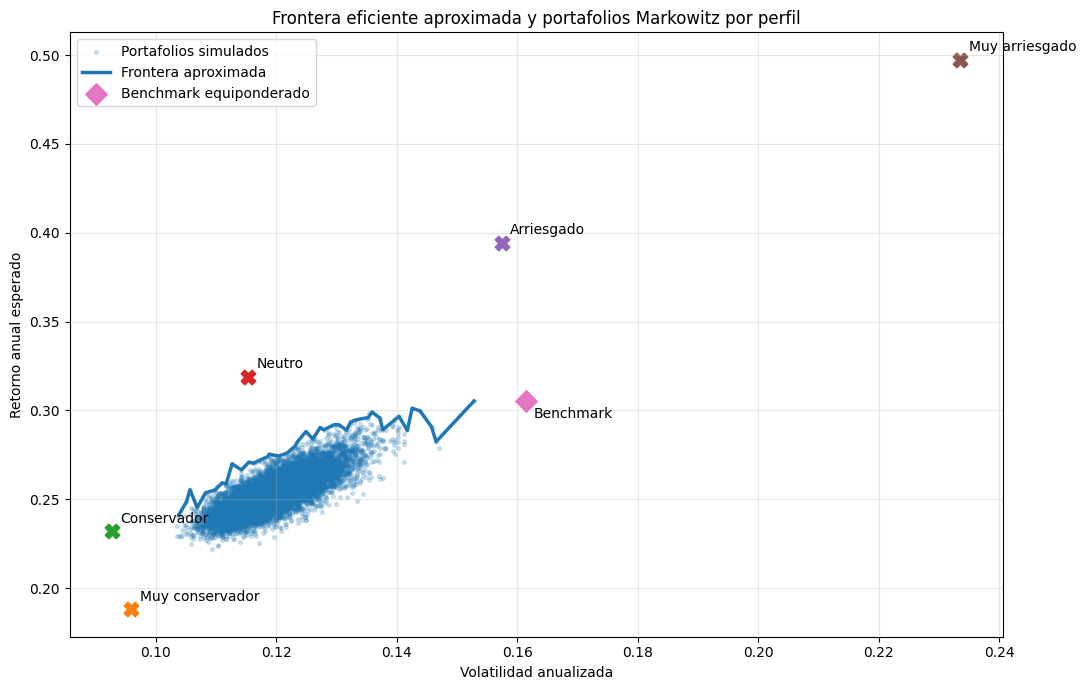

In [19]:
# ============================================================
# 15. Gráfico de frontera eficiente aproximada
# ============================================================

plt.figure(figsize=(11, 7))
plt.scatter(
    df_simulados["volatilidad_anual"],
    df_simulados["retorno_anual"],
    s=7,
    alpha=0.20,
    label="Portafolios simulados",
)
plt.plot(
    df_frontera_aprox["volatilidad_anual"],
    df_frontera_aprox["retorno_anual"],
    linewidth=2.5,
    label="Frontera aproximada",
)

for _, fila in df_resultados_markowitz.iterrows():
    plt.scatter(fila["volatilidad_anual"], fila["retorno_anual"], s=110, marker="X")
    plt.annotate(fila["perfil"], (fila["volatilidad_anual"], fila["retorno_anual"]), xytext=(6, 6), textcoords="offset points")

plt.scatter(metricas_benchmark["volatilidad_anual"], metricas_benchmark["retorno_anual"], s=120, marker="D", label="Benchmark equiponderado")
plt.annotate("Benchmark", (metricas_benchmark["volatilidad_anual"], metricas_benchmark["retorno_anual"]), xytext=(6, -12), textcoords="offset points")

plt.xlabel("Volatilidad anualizada")
plt.ylabel("Retorno anual esperado")
plt.title("Frontera eficiente aproximada y portafolios Markowitz por perfil")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_SALIDA / "frontera_eficiente_aproximada.png", dpi=180)
plt.show()

## 11. Valorización futura de los portafolios: 2026--2031

La valorización ya no se calcula como desempeño histórico dentro de la ventana usada para estimar el modelo. En su lugar, se proyecta el valor futuro del portafolio desde 2026 hasta 2031.

Se construyen dos salidas:

1. **Curva esperada**: usa el retorno semanal promedio estimado del portafolio.
2. **Bandas de incertidumbre**: usa simulación bootstrap, remuestreando retornos semanales históricos del portafolio. Esto permite proyectar escenarios sin imponer explícitamente normalidad sobre los retornos.


In [20]:
# ============================================================
# 16. Proyección futura de riqueza 2026--2031
# ============================================================

def retorno_portafolio_historico(retornos_ventana: pd.DataFrame, pesos: pd.Series) -> pd.Series:
    '''Calcula la serie histórica de retornos del portafolio con pesos fijos.'''
    comunes = [t for t in pesos.index if t in retornos_ventana.columns]
    w = pesos.loc[comunes]
    w = w / w.sum()
    r = retornos_ventana[comunes].fillna(0.0) @ w.values
    return r


def proyectar_riqueza_esperada(retorno_semanal_esperado: float) -> pd.Series:
    '''Proyecta riqueza futura usando un retorno semanal esperado constante.'''
    pasos = np.arange(len(FECHAS_PROYECCION))
    riqueza = CAPITAL_INICIAL * (1.0 + retorno_semanal_esperado) ** pasos
    return pd.Series(riqueza, index=FECHAS_PROYECCION)


def simular_riqueza_bootstrap(
    retornos_historicos_portafolio: pd.Series,
    n_simulaciones: int = N_SIMULACIONES_PROYECCION,
    seed: int = RANDOM_STATE_PROYECCION,
) -> pd.DataFrame:
    '''Simula trayectorias futuras usando bootstrap de retornos históricos semanales.

    En cada semana futura se toma aleatoriamente, con reemplazo, un retorno observado
    en la ventana histórica de estimación. Esto preserva empíricamente colas, asimetrías
    y shocks históricos sin imponer una distribución normal.
    '''
    rng = np.random.default_rng(seed)
    r_hist = retornos_historicos_portafolio.dropna().astype(float).values

    if len(r_hist) == 0:
        raise ValueError("No hay retornos históricos suficientes para simular.")

    # Se simulan retornos futuros para las 260 semanas posteriores al inicio.
    retornos_sim = rng.choice(
        r_hist,
        size=(N_SEMANAS_PROYECCION, n_simulaciones),
        replace=True,
    )

    # Protección ante retornos extremos por errores de datos.
    retornos_sim = np.clip(retornos_sim, -0.95, 3.0)

    riqueza = np.empty((N_SEMANAS_PROYECCION + 1, n_simulaciones))
    riqueza[0, :] = CAPITAL_INICIAL
    riqueza[1:, :] = CAPITAL_INICIAL * np.cumprod(1.0 + retornos_sim, axis=0)

    return pd.DataFrame(riqueza, index=FECHAS_PROYECCION)


series_riqueza_esperada = {}
registros_parametros_proyeccion = []
registros_percentiles = []
riquezas_simuladas_por_portafolio = {}

# Portafolios Markowitz por perfil.
for perfil, pesos in pesos_por_perfil.items():
    r_hist = retorno_portafolio_historico(retornos_10_anios, pesos)
    retorno_sem_esperado = float(r_hist.mean())
    volatilidad_sem = float(r_hist.std())

    riqueza_esp = proyectar_riqueza_esperada(retorno_sem_esperado)
    riqueza_sim = simular_riqueza_bootstrap(r_hist, seed=RANDOM_STATE_PROYECCION)

    series_riqueza_esperada[perfil] = riqueza_esp
    riquezas_simuladas_por_portafolio[perfil] = riqueza_sim

    percentiles = riqueza_sim.quantile(
        [p / 100 for p in PERCENTILES_PROYECCION],
        axis=1,
    ).T
    percentiles.columns = [f"p{p}" for p in PERCENTILES_PROYECCION]
    percentiles.insert(0, "portafolio", perfil)
    percentiles.insert(1, "fecha", percentiles.index)
    registros_percentiles.append(percentiles.reset_index(drop=True))

    registros_parametros_proyeccion.append({
        "portafolio": perfil,
        "retorno_semanal_esperado": retorno_sem_esperado,
        "volatilidad_semanal_hist": volatilidad_sem,
        "retorno_anualizado_esperado": (1 + retorno_sem_esperado) ** SEMANAS_POR_ANIO - 1,
        "volatilidad_anualizada_hist": volatilidad_sem * np.sqrt(SEMANAS_POR_ANIO),
        "riqueza_esperada_2031": float(riqueza_esp.iloc[-1]),
        "riqueza_p5_2031": float(percentiles["p5"].iloc[-1]),
        "riqueza_p50_2031": float(percentiles["p50"].iloc[-1]),
        "riqueza_p95_2031": float(percentiles["p95"].iloc[-1]),
    })

# Benchmark equiponderado.
nombre_benchmark = f"Benchmark top {N_EMPRESAS_BENCHMARK}"
r_bench = retorno_portafolio_historico(retornos_10_anios, pesos_benchmark)
retorno_sem_bench = float(r_bench.mean())
volatilidad_sem_bench = float(r_bench.std())

riqueza_esp_bench = proyectar_riqueza_esperada(retorno_sem_bench)
riqueza_sim_bench = simular_riqueza_bootstrap(r_bench, seed=RANDOM_STATE_PROYECCION)

series_riqueza_esperada[nombre_benchmark] = riqueza_esp_bench
riquezas_simuladas_por_portafolio[nombre_benchmark] = riqueza_sim_bench

percentiles_bench = riqueza_sim_bench.quantile(
    [p / 100 for p in PERCENTILES_PROYECCION],
    axis=1,
).T
percentiles_bench.columns = [f"p{p}" for p in PERCENTILES_PROYECCION]
percentiles_bench.insert(0, "portafolio", nombre_benchmark)
percentiles_bench.insert(1, "fecha", percentiles_bench.index)
registros_percentiles.append(percentiles_bench.reset_index(drop=True))

registros_parametros_proyeccion.append({
    "portafolio": nombre_benchmark,
    "retorno_semanal_esperado": retorno_sem_bench,
    "volatilidad_semanal_hist": volatilidad_sem_bench,
    "retorno_anualizado_esperado": (1 + retorno_sem_bench) ** SEMANAS_POR_ANIO - 1,
    "volatilidad_anualizada_hist": volatilidad_sem_bench * np.sqrt(SEMANAS_POR_ANIO),
    "riqueza_esperada_2031": float(riqueza_esp_bench.iloc[-1]),
    "riqueza_p5_2031": float(percentiles_bench["p5"].iloc[-1]),
    "riqueza_p50_2031": float(percentiles_bench["p50"].iloc[-1]),
    "riqueza_p95_2031": float(percentiles_bench["p95"].iloc[-1]),
})

df_riqueza_proyectada = pd.DataFrame(series_riqueza_esperada)
df_percentiles_proyeccion = pd.concat(registros_percentiles, ignore_index=True)
df_parametros_proyeccion = pd.DataFrame(registros_parametros_proyeccion)

df_parametros_proyeccion


,portafolio,retorno_semanal_esperado,volatilidad_semanal_hist,retorno_anualizado_esperado,volatilidad_anualizada_hist,riqueza_esperada_2031,riqueza_p5_2031,riqueza_p50_2031,riqueza_p95_2031
0,Muy conservador,0.003616,0.013912,0.206485,0.100320,2556.287773,1717.196246,2493.979467,3588.322497
1,Conservador,0.004464,0.013407,0.260633,0.096679,3183.782015,2191.388357,3128.426076,4412.366135
2,Neutro,0.006136,0.016578,0.374480,0.119543,4905.591625,3011.605051,4752.196044,7267.247543
3,Arriesgado,0.007585,0.022562,0.481337,0.162695,7132.945946,3622.571973,6695.947882,12090.596993
4,Muy arriesgado,0.009565,0.033346,0.640512,0.240460,11882.211887,4345.749066,10232.626371,24873.034423
5,Benchmark top 20,0.005871,0.023383,0.355803,0.168615,4581.245765,2216.209549,4317.887758,7898.844458


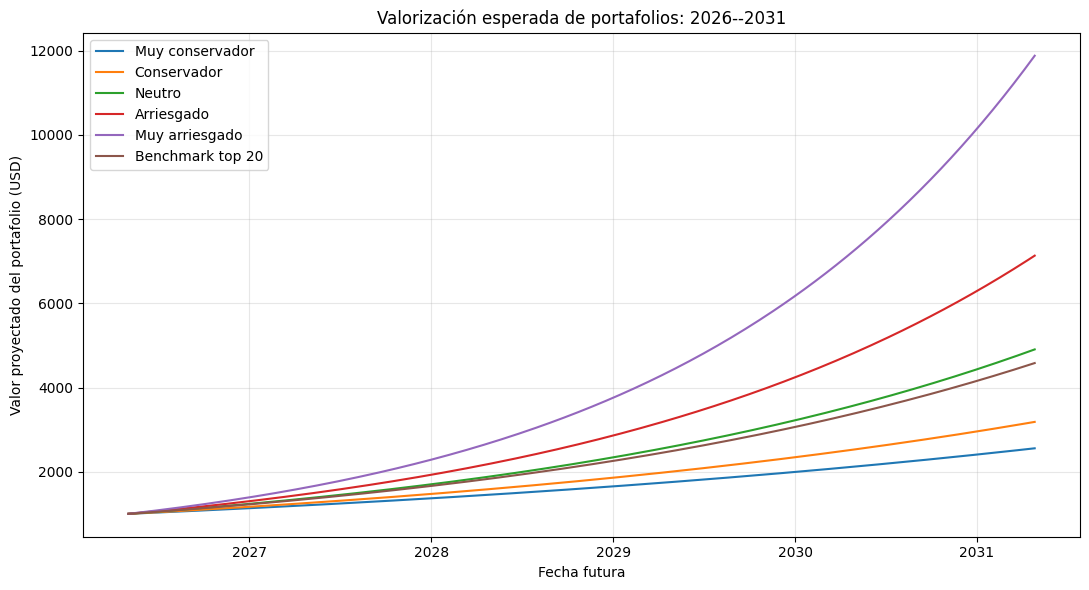

In [21]:
# Gráfico de valorización esperada futura
plt.figure(figsize=(11, 6))
for col in df_riqueza_proyectada.columns:
    plt.plot(df_riqueza_proyectada.index, df_riqueza_proyectada[col], label=col)

plt.title("Valorización esperada de portafolios: 2026--2031")
plt.xlabel("Fecha futura")
plt.ylabel("Valor proyectado del portafolio (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_SALIDA / "valorizacion_esperada_2026_2031.png", dpi=180)
plt.show()


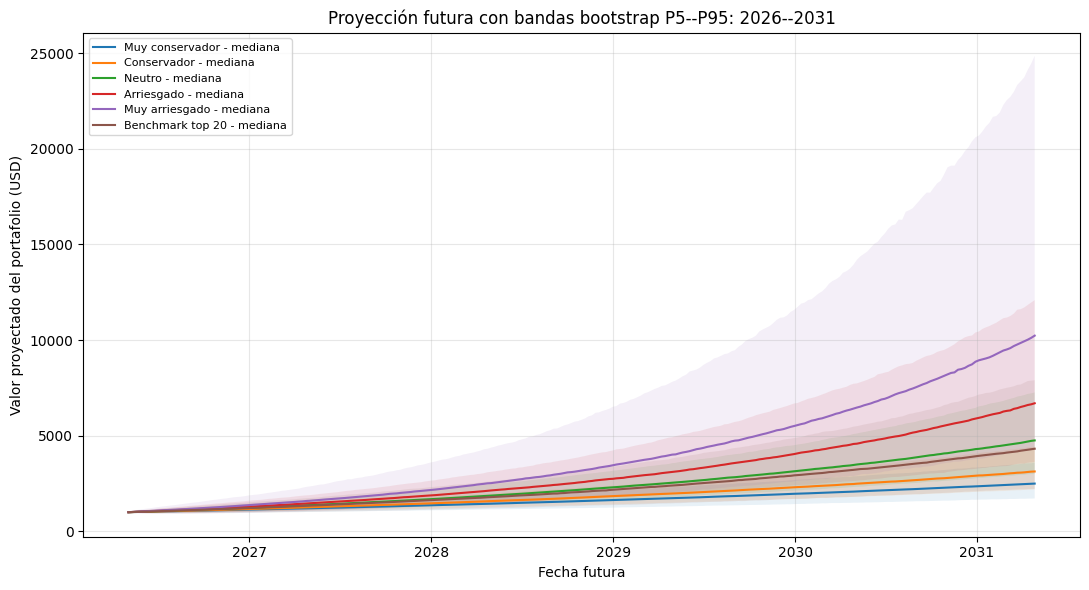

In [22]:
# Gráfico de bandas de incertidumbre por bootstrap
# Para evitar saturar la figura, se muestran las bandas P5-P95 y la mediana simulada.
plt.figure(figsize=(11, 6))

for portafolio in df_percentiles_proyeccion["portafolio"].unique():
    aux = df_percentiles_proyeccion[df_percentiles_proyeccion["portafolio"] == portafolio].copy()
    fechas = pd.to_datetime(aux["fecha"])
    plt.plot(fechas, aux["p50"], label=f"{portafolio} - mediana")
    plt.fill_between(fechas, aux["p5"], aux["p95"], alpha=0.10)

plt.title("Proyección futura con bandas bootstrap P5--P95: 2026--2031")
plt.xlabel("Fecha futura")
plt.ylabel("Valor proyectado del portafolio (USD)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RUTA_SALIDA / "bandas_bootstrap_2026_2031.png", dpi=180)
plt.show()


In [23]:
# ============================================================
# 17. Exportación de resultados
# ============================================================

df_comparacion.to_csv(RUTA_SALIDA / "comparacion_markowitz_vs_benchmark.csv", index=False, encoding="utf-8-sig")
df_pesos_markowitz.to_csv(RUTA_SALIDA / "pesos_markowitz_por_perfil.csv", index=False, encoding="utf-8-sig")
df_benchmark.to_csv(RUTA_SALIDA / "benchmark_equiponderado_top20.csv", index=False, encoding="utf-8-sig")
df_stats_activos.to_csv(RUTA_SALIDA / "estadisticas_activos_10_anios_efectivos.csv", index=False, encoding="utf-8-sig")
df_simulados.to_csv(RUTA_SALIDA / "portafolios_simulados_frontera.csv", index=False, encoding="utf-8-sig")
df_frontera_aprox.to_csv(RUTA_SALIDA / "frontera_eficiente_aproximada.csv", index=False, encoding="utf-8-sig")
df_riqueza_proyectada.to_csv(RUTA_SALIDA / "valorizacion_esperada_2026_2031.csv", encoding="utf-8-sig")
df_percentiles_proyeccion.to_csv(RUTA_SALIDA / "percentiles_bootstrap_2026_2031.csv", index=False, encoding="utf-8-sig")
df_parametros_proyeccion.to_csv(RUTA_SALIDA / "resumen_proyeccion_2026_2031.csv", index=False, encoding="utf-8-sig")

print("Resultados exportados en:")
print(RUTA_SALIDA)


Resultados exportados en:
/content/Resultados_Markowitz


## 12. Comentarios sobre la mejora metodológica

Esta variante corrige la interpretación temporal de la valorización:

1. **Ventana histórica solo para estimar parámetros**: los retornos esperados y covarianzas se calculan usando 10 años efectivos de información disponible antes de 2026.
2. **Sin pandemia en la estimación**: al trabajar con la base filtrada y eliminar semanas completamente vacías, la ventana histórica evita que 2020--2022 distorsione la muestra.
3. **Valorización hacia adelante**: la riqueza acumulada se proyecta desde 2026 hasta 2031, por lo que los gráficos ya no representan desempeño pasado sino valorización futura esperada.
4. **Bootstrap para incertidumbre**: las bandas P5--P95 se obtienen remuestreando retornos históricos del portafolio, evitando imponer una distribución normal sobre los retornos.
5. **Cómputo eficiente**: se mantiene una sola optimización por perfil y la frontera se aproxima con simulación vectorizada.

La proyección no debe interpretarse como predicción garantizada de precios futuros, sino como una valorización condicional a los retornos históricos estimados y a los pesos recomendados por Markowitz.
